# 1. Distance Modulus

Theory `snia.cosmology`.

1. Comoving distance from the FLRW metric
2. Why the distances here are dimensionless
3. The three curvature branches
4. $D_A$, $D_L$ -- Etherington duality
5. The distance modulus and the $H_0$–$M_B$ degeneracy

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from snia.cosmology import FLRW

plt.rcParams["figure.figsize"] = (7, 4)

lcdm = FLRW(omega_m=0.3, omega_lambda=0.7)
print(lcdm)

FLRW(omega_m=0.3, omega_lambda=0.7)  # omega_k=+0, q0=-0.55


## 1. Comoving distance

The cosmological principle forces the metric into the FLRW form,

$$
ds^{2} = -c^{2}dt^{2} + a^{2}(t)\big[d\chi^{2} + S_{k}^{2}(\chi)\,d\Omega^{2}\big],
$$

$$
\chi(z) = \int_0^z \frac{c\,dz'}{H(z')}.
$$

The Friedmann equation supplies $H$:

$$
H^{2}(z) = H_0^{2}\big[\Omega_m(1+z)^{3} + \Omega_k(1+z)^{2} + \Omega_\Lambda\big]
\equiv H_0^{2}E^{2}(z).
$$

Each term scales with how that component dilutes: matter as $a^{-3}$, curvature
as $a^{-2}$, and $\Lambda$ as $a^{0}$. Setting $z=0$ gives

$$
\Omega_k = 1 - \Omega_m - \Omega_\Lambda,
$$

so curvature is **derived, not fitted**, and $E(z=0) = 1$ is an identity.

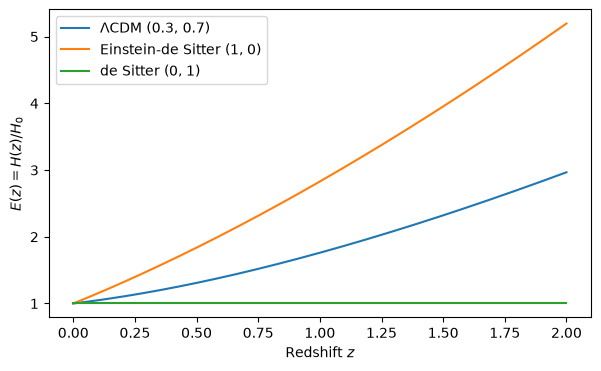

In [66]:
z = np.linspace(0, 2, 200)

plt.plot(z, FLRW(0.3, 0.7).E(z), label=r"$\Lambda$CDM (0.3, 0.7)")
plt.plot(z, FLRW(1.0, 0.0).E(z), label="Einstein-de Sitter (1, 0)")
plt.plot(z, FLRW(0.0, 1.0).E(z), label="de Sitter (0, 1)")
plt.xlabel("Redshift $z$")
plt.ylabel("$E(z) = H(z)/H_0$")
plt.legend()
plt.show()

## 2. Why the distances are dimensionless

Every distance carries the same prefactor $c/H_0$:

$$
\chi(z) = \frac{c}{H_0}\underbrace{\int_0^z\frac{dz'}{E(z')}}_{I(z)}.
$$

$I(z)$ depends only on $(\Omega_m, \Omega_\Lambda)$. The library computes $I$ and
never multiplies by $c/H_0$, given that supernovae cannot constrain $H_0$, so carrying it
around would smuggle in a parameter the data cannot measure.

In [67]:
print("Comoving_distance returns the dimensionless I(z):")
for redshift in [0.1, 0.5, 1.0]:
    print(f"   I({redshift}) = {lcdm.comoving_distance(redshift):.4f}")

print("\nYou supply H0 yourself to get Mpc:")
c_km_s = 299792.458
for hubble_constant in [67.4, 70.0, 73.0]:
    mpc = lcdm.comoving_distance(1.0) * c_km_s / hubble_constant
    print(f"   H0 = {hubble_constant}  ->  chi(1) = {mpc:.0f} Mpc")

Comoving_distance returns the dimensionless I(z):
   I(0.1) = 0.0977
   I(0.5) = 0.4410
   I(1.0) = 0.7714

You supply H0 yourself to get Mpc:
   H0 = 67.4  ->  chi(1) = 3431 Mpc
   H0 = 70.0  ->  chi(1) = 3304 Mpc
   H0 = 73.0  ->  chi(1) = 3168 Mpc


## 3. The three curvature branches are one function

With $R = (c/H_0)/\sqrt{|\Omega_k|}$, the transverse comoving distance is

$$
D_M =
\begin{cases}
\sinh(\sqrt{\Omega_k}\,I)/\sqrt{\Omega_k} & \Omega_k > 0\\
I & \Omega_k = 0\\
\sin(\sqrt{|\Omega_k|}\,I)/\sqrt{|\Omega_k|} & \Omega_k < 0
\end{cases}
$$

These are not three cases. Writing $x = \Omega_k I^{2}$,

$$
\frac{\sinh\sqrt{x}}{\sqrt{x}} = 1 + \frac{x}{6} + \frac{x^{2}}{120}
+ \frac{x^{3}}{5040} + \dots
$$

Only **even** powers of $\sqrt{x}$ appear, so the series is entire in $x$ and
covers all three cases: for $x<0$ it is $\sin\sqrt{|x|}/\sqrt{|x|}$, and at
$x=0$ it is exactly 1.

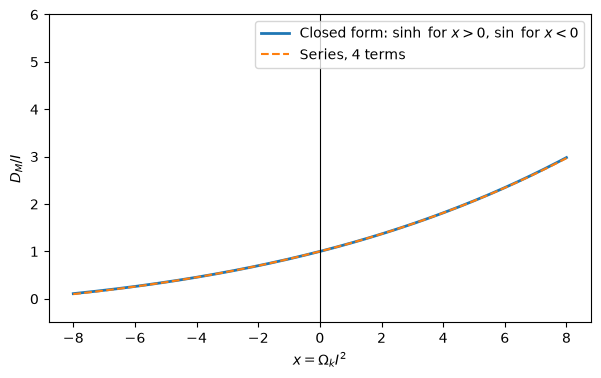

In [68]:
x = np.linspace(-8, 8, 400)       
sqrt_x = np.sqrt(np.abs(x))
closed_form = np.where(x > 0, np.sinh(sqrt_x) / sqrt_x, np.sin(sqrt_x) / sqrt_x)
series = 1 + x / 6 + x**2 / 120 + x**3 / 5040

plt.plot(x, closed_form, lw=2, label=r"Closed form: $\sinh$ for $x>0$, $\sin$ for $x<0$")
plt.plot(x, series, "--", label="Series, 4 terms")
plt.axvline(0, color="k", lw=0.8)
plt.ylim(-0.5, 6)
plt.xlabel(r"$x = \Omega_k I^2$")
plt.ylabel(r"$D_M / I$")
plt.legend()
plt.show()

## 4. Angular diameter and luminosity distance

**Angular diameter distance.** A source of proper size $\ell$ subtends
$\delta\theta = \ell/D_A$. In the metric, its proper transverse size *at
emission* is $a(t_e)S_k(\chi)\delta\theta = S_k(\chi)\delta\theta/(1+z)$, so

$$
D_A = \frac{D_M}{1+z}.
$$

**Luminosity distance.** Flux is $F = L/(4\pi D_L^{2})$. Three effects: photons
spread over an area $4\pi D_M^{2}$ today; each photon is redshifted by $(1+z)$;
and arrival times are dilated by another $(1+z)$. So

$$
D_L = (1+z)\,D_M.
$$

**Etherington duality.** Combining the two,

$$
D_L = (1+z)^{2}D_A.
$$

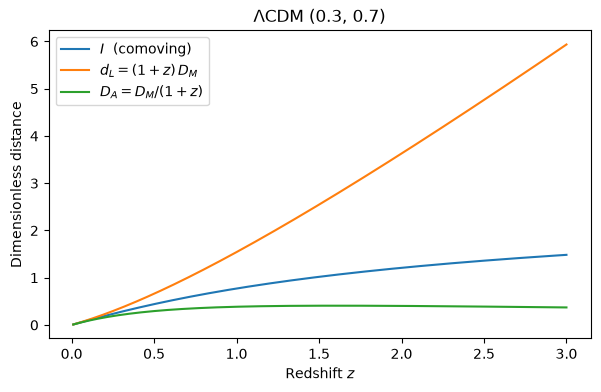

In [69]:
z = np.linspace(0.01, 3, 300)

plt.plot(z, lcdm.comoving_distance(z), label=r"$I$  (comoving)")
plt.plot(z, lcdm.luminosity_distance(z), label=r"$d_L = (1+z)\,D_M$")
plt.plot(z, lcdm.angular_diameter_distance(z), label=r"$D_A = D_M/(1+z)$")
plt.xlabel("Redshift $z$")
plt.ylabel("Dimensionless distance")
plt.title(r"$\Lambda$CDM (0.3, 0.7)")
plt.legend()
plt.show()

In [70]:
z = np.array([0.1, 0.5, 1.0, 1.414])

print("Etherington:  D_L / [(1+z)^2 D_A] - 1")
for omega_m, omega_lambda in [(0.3, 0.7), (0.3, 1.2), (1.0, 0.0), (1.7, -0.5)]:
    model = FLRW(omega_m, omega_lambda)
    ratio = model.luminosity_distance(z) / ((1 + z) ** 2 * model.angular_diameter_distance(z))
    print(f"   ({omega_m}, {omega_lambda}):  {np.abs(ratio - 1).max():.1e}")

Etherington:  D_L / [(1+z)^2 D_A] - 1
   (0.3, 0.7):  2.2e-16
   (0.3, 1.2):  2.2e-16
   (1.0, 0.0):  1.1e-16
   (1.7, -0.5):  2.2e-16


## 5. The distance modulus, and why $H_0$ cannot be fitted

By the definition of magnitudes, the distance modulus of a source at
luminosity distance $D_L$ is

$$
\mu \equiv 5\log_{10}\!\left(\frac{D_L}{\rm Mpc}\right) + 25.
$$

Insert $D_L = (c/H_0)\,d_L$. **The logarithm turns the product into a sum**,
and that is the whole trick:

$$
5\log_{10}\!\left(\frac{D_L}{\rm Mpc}\right) + 25
= \underbrace{5\log_{10} d_L(z;\Omega_m,\Omega_\Lambda)}_{\text{shape, dimensionless}}
\;+\;\underbrace{5\log_{10}\!\left(\frac{c}{H_0\,{\rm Mpc}}\right) + 25}_{\text{constant in }z} .
$$

Only the first term depends on the cosmology. Call it the **shape**:

$$
\mu_{\rm shape}(z;\Omega_m,\Omega_\Lambda) \equiv 5\log_{10} d_L(z;\Omega_m,\Omega_\Lambda) .
$$

### The data side

The tabulated Union2.1 $\mu^{\rm obs}$ was built with the Tripp estimator,
which needs an absolute magnitude to exist at all:

$$
\mu^{\rm obs} \equiv m_B^\star - M_B^{\rm fid} + \alpha x_1 - \beta c
+ \delta P_{\rm host},
$$

using a fiducial $M_B^{\rm fid} = -19.308$ at $h = 0.7$, recorded in the file
header. That choice is arbitrary: $M_B$ is not predicted by theory and has to
be calibrated externally, and fixing it imports an $H_0$ assumption.

### Putting the two together

The corrected apparent magnitude obeys

$$
m_B^\star + \alpha x_1 - \beta c + \delta P_{\rm host}
= M_B + \mu_{\rm shape}(z) + 25 + 5\log_{10}\frac{c}{H_0\,{\rm Mpc}},
$$

so every constant collapses into one free offset:

$$
\boxed{\;\mu_{\rm th}(z) = \mu_{\rm shape}(z;\Omega_m,\Omega_\Lambda) + \mathcal{M},
\qquad
\mathcal{M} \equiv M_B + 25 + 5\log_{10}\!\left(\frac{c}{H_0\,{\rm Mpc}}\right)\;}
$$

This is the form used in the lecture slides, and it is exactly what the library
computes: `distance_modulus(z, m_offset)` returns
$\mu_{\rm shape}(z) + \texttt{m\_offset}$, with **no** $+25$ and **no** $c/H_0$
hidden inside.

One trap to avoid. $\mathcal{M}$ must not be added on top of
$5\log_{10}(D_L/{\rm Mpc}) + 25$: that expression *already* carries the $+25$
and the $c/H_0$, so adding $\mathcal{M}$ would count them twice — a 43 mag
error. $\mathcal{M}$ is added to the **shape**, never to a complete distance
modulus.

### What $M_B$ means here, numerically

Since the released $\mu^{\rm obs}$ already had $M_B^{\rm fid}$ removed, the
$M_B$ inside $\mathcal{M}$ is the offset *relative to that fiducial*,
$M_B - M_B^{\rm fid}$. So for $h = 0.7$

$$
\mathcal{M} \simeq 25 + 5\log_{10}\!\left(\frac{c}{H_0\,{\rm Mpc}}\right) = 43.16 ,
$$

and notebook 3 fits $\hat{\mathcal{M}} = 43.17$ straight from the data. The
leftover $0.01$ mag *is* $M_B - M_B^{\rm fid}$, which confirms that the release
really was calibrated at $h = 0.7$.

Had we instead fitted apparent magnitudes with no fiducial removed, the same
formula would give $\mathcal{M} = -19.31 + 43.16 = 23.86$. Same equation,
different observable, worth keeping straight when comparing with other papers.

### The degeneracy

$H_0$ and $M_B$ enter **only** through the sum $\mathcal{M}$. Raising $H_0$ and
dimming every supernova to match produces identical data, so the likelihood is
exactly flat along that ridge and a chain sampling $H_0$ separately would never
converge.

That is why $\mathcal{M}$ is a single nuisance parameter, marginalized
analytically (notebook 3).

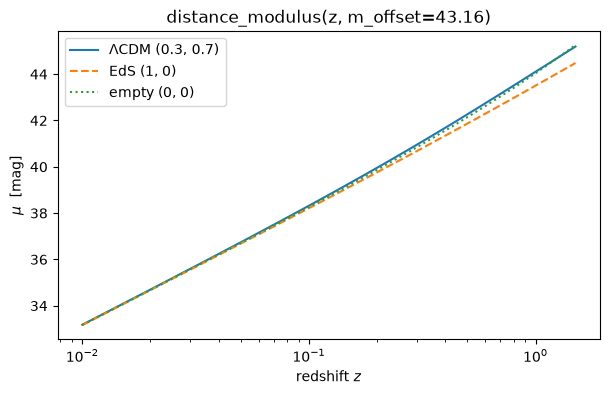

In [71]:
z = np.logspace(-2, np.log10(1.5), 200)

plt.plot(z, FLRW(0.3, 0.7).distance_modulus(z, 43.16), label=r"$\Lambda$CDM (0.3, 0.7)")
plt.plot(z, FLRW(1.0, 0.0).distance_modulus(z, 43.16), "--", label="EdS (1, 0)")
plt.plot(z, FLRW(0.0, 0.0).distance_modulus(z, 43.16), ":", label="empty (0, 0)")
plt.xscale("log")
plt.xlabel("redshift $z$")
plt.ylabel(r"$\mu$  [mag]")
plt.title(r"distance_modulus(z, m_offset=43.16)")
plt.legend()
plt.show()

In [72]:
# The degeneracy: raise H0 and dim the supernovae to match. mu does not move.
c_km_s = 299792.458
M_B_FIDUCIAL = -19.308          # what the release assumed, at h = 0.7
z = np.array([0.1, 0.5, 1.0])

print("    H0       M_B    script_M      mu(0.1)    mu(0.5)    mu(1.0)")
for hubble_constant in [60.0, 70.0, 80.0]:
    # brighter/fainter M_B exactly compensates the change in H0
    delta_M_B = 5 * np.log10(hubble_constant / 70.0)
    script_m = delta_M_B + 25 + 5 * np.log10(c_km_s / hubble_constant)
    mu = lcdm.distance_modulus(z, script_m)
    print(f"  {hubble_constant:5.1f}  {M_B_FIDUCIAL + delta_M_B:8.4f}  {script_m:9.5f}   "
          + "  ".join(f"{value:8.5f}" for value in mu))

print("\nOnly the combination M_B + 5log10(c/H0) is observable.")

    H0       M_B    script_M      mu(0.1)    mu(0.5)    mu(1.0)
   60.0  -19.6427   43.15861   38.31520  42.26119  44.10024
   70.0  -19.3080   43.15861   38.31520  42.26119  44.10024
   80.0  -19.0180   43.15861   38.31520  42.26119  44.10024

Only the combination M_B + 5log10(c/H0) is observable.


## Summary

| quantity | formula | method |
| --- | --- | --- |
| expansion rate | $E^2 = \Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_\Lambda$ | `E`, `E_squared` |
| comoving | $I = \int_0^z dz'/E$ | `comoving_distance` |
| transverse | $D_M = S_k(I)$ | `transverse_comoving_distance` |
| angular diameter | $D_A = D_M/(1+z)$ | `angular_diameter_distance` |
| luminosity | $d_L = (1+z)D_M$ | `luminosity_distance` |
| shape | $\mu_{\rm shape} = 5\log_{10}d_L$ | `distance_modulus(z, 0)` |
| distance modulus | $\mu_{\rm th} = \mu_{\rm shape} + \mathcal{M}$ | `distance_modulus(z, m_offset)` |
